# ta-dbscan Stop Detection

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# Imports
import nomad.io.base as loader
import geopandas as gpd
from shapely.geometry import box
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry, plot_circles
import nomad.stop_detection.dbscan as DBSCAN

import nomad.data as data_folder
from pathlib import Path

from nomad.city_gen import City
import pandas as pd
import datetime
import json
import matplotlib.dates as mdates
import pandas as pd
import nomad.generation.viz as viz
from nomad.traj_gen import Agent, condense_destinations
import nomad.stop_detection.utils as utils

In [2]:
# Parameters according to the config file
data_dir = Path(data_folder.__file__).parent
city = City.from_geopackage(data_dir / "garden-city.gpkg")
buildings = gpd.read_parquet(data_dir / "garden-city-buildings-mercator.parquet")

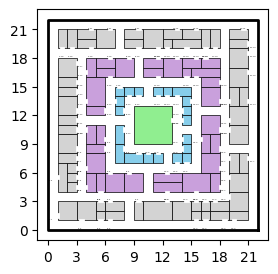

In [3]:
fig, ax = plt.subplots(figsize=(3,3))

city.plot_city(ax=ax)

# Destination Diary for 2 stop trajectory

In [4]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=2, freq='90min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [90]*2  # in minutes

location = ['w-x17-y10'] + ['r-x19-y11']


destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)

destinations = condense_destinations(destinations)
destinations

,datetime,timestamp,duration,location
0,2024-06-01 00:00:00-08:00,1717228800,90,w-x17-y10
1,2024-06-01 01:30:00-08:00,1717234200,90,r-x19-y11


In [98]:
seed = 35 #33
dist_thresh = 7.5/15
time_thresh=120
dur_min=5
min_pts = 3
ha=15/15

Charlie = Agent(identifier="Andres",
                city=city)

Charlie.generate_trajectory(destination_diary=destinations,
                            seed=seed,
                            dt=0.15)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=6,
                          seed=seed,
                          ha=ha)



### Plot normal stops

In [99]:
traj = Charlie.sparse_traj
labels = DBSCAN.ta_dbscan_labels(traj,
                                time_thresh=time_thresh,
                                dist_thresh=dist_thresh,
                                min_pts=3,
                                timestamp='timestamp')

merged = traj.join(labels)

### Remove overlaps

In [100]:
if labels.loc[labels!=-1].nunique() > 1:
    # Get adjusted cluster labels (not summary table)
    adjusted_labels = DBSCAN.remove_overlaps(
        merged,
        dist_thresh=dist_thresh,
        min_pts=min_pts,
        time_thresh=time_thresh,
        method="cluster",
        timestamp="timestamp",
        summarize_stops=False,
        )
    
    merged['cluster_adjusted'] = adjusted_labels

stops = merged.groupby('cluster', as_index=False, sort=False).apply(
    lambda grp: utils.summarize_stop(
        grp,
        complete_output=False,
        timestamp='timestamp'),
    include_groups=False
)

In [101]:
if 'cluster_adjusted' in merged:
    print(merged[['cluster', 'cluster_adjusted']])
else:
    print(merged['cluster'])
traj = merged

            cluster  cluster_adjusted
timestamp                            
1717229091        0                -1
1717229263        0                -1
1717229448        1                -1
1717229552        0                 0
1717229700       -1                -1
1717230880        0                 0
1717232071       -1                -1
1717232233       -1                -1
1717232737        0                 0
1717232787        0                 0
1717233106        0                 0
1717233268       -1                -1
1717233285        0                 0
1717233294       -1                -1
1717233445        0                 0
1717233810        0                 0
1717233820        0                 0
1717234210        1                -1
1717234259        1                -1
1717234500       -1                -1
1717234679        2                -1
1717235098       -1                -1
1717235511       -1                -1
1717236074        3                -1
1717236276  

In [104]:
traj['cluster'] = traj['cluster_adjusted']

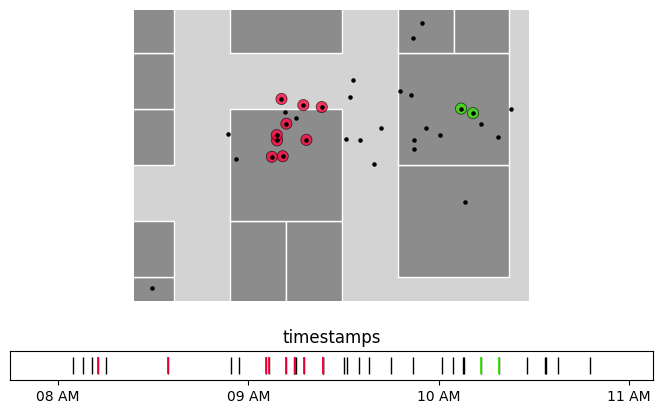

In [105]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(7,4.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.1, color='cluster', cmap='prism_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=5, color='black')
#ax_map.set_axis_off()
plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
#plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.5, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='prism_r', set_xlim=False, lw=1.3)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('normal_clusters.svg' , format='svg')
plt.savefig('normal_clusters.png' , format='png', dpi=300)
plt.show()

### Ground truth, undersmoothing oversmoothing

In [8]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=6, freq='30min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [30]*6  # in minutes

location = ['p-x12-y11'] * 1 + ['h-x14-y11'] * 1 + ['w-x17-y10'] * 2 + ['r-x19-y11'] * 2

destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)
destinations = condense_destinations(destinations)

Charlie = Agent(identifier="Paco", city=city)

# Convert datetime column
# destinations['datetime'] = pd.to_datetime(destinations['datetime'])
Charlie.generate_trajectory(destination_diary=destinations,
                            seed=1005,
                            dt=0.15)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=5.3,
                          seed=1005,
                          ha=9/15)



In [9]:
dt_max=220
dur_min=5

output = []
## Undersmoothing
delta_roam = 0.8
traj = Charlie.sparse_traj.copy()
stops = LACHESIS.lachesis(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, 
                         complete_output=True, keep_col_names=True, timestamp='timestamp')
labels = LACHESIS.lachesis_labels(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, timestamp='timestamp')
traj['cluster'] = labels
output += [(traj, stops)]
## Normal
delta_roam = 3.9
traj = Charlie.sparse_traj.copy()
stops = LACHESIS.lachesis(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, 
                         complete_output=True, keep_col_names=True, timestamp='timestamp')
labels = LACHESIS.lachesis_labels(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, timestamp='timestamp')
traj['cluster'] = labels
output += [(traj, stops)]
## Oversmoothing
delta_roam = 6
traj = Charlie.sparse_traj.copy()
stops = LACHESIS.lachesis(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, 
                         complete_output=True, keep_col_names=True, timestamp='timestamp')
labels = LACHESIS.lachesis_labels(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, timestamp='timestamp')
traj['cluster'] = labels
output += [(traj, stops)]


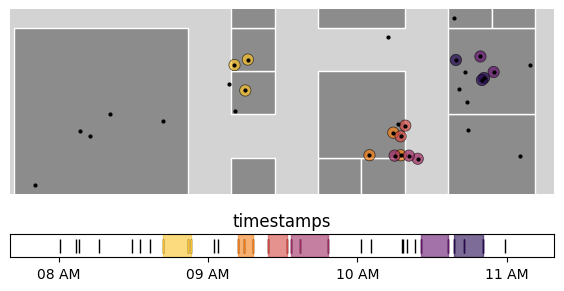

In [10]:
## Undersmoothing 
traj, stops = output[0]
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,3.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.13, alpha=0.7, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=4, color='black')
#ax_map.set_axis_off()
plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='inferno_r', set_xlim=False, lw=1)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('undersmooth_clusters.svg' , format='svg')
plt.savefig('undersmooth_clusters.png' , format='png', dpi=300)
plt.show()

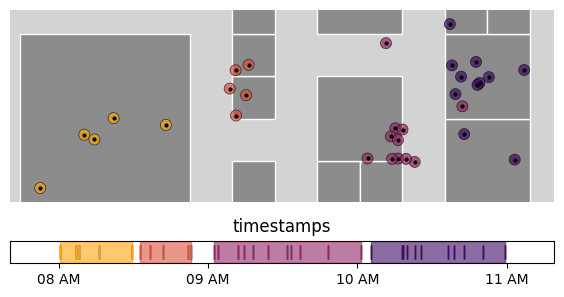

In [11]:
## Normal 
traj, stops = output[1]
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,3.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.13, alpha=0.7, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=4, color='black')
#ax_map.set_axis_off()
plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='inferno_r', set_xlim=False, lw=1)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('good_clusters.svg' , format='svg')
plt.savefig('good_clusters.png' , format='png', dpi=300)
plt.show()

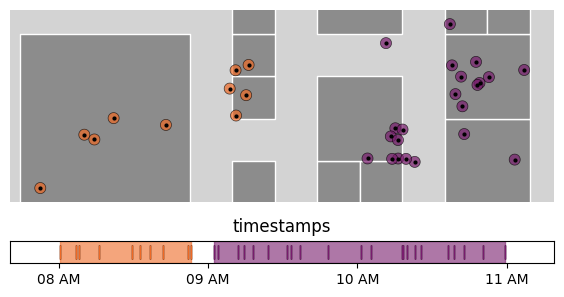

In [12]:
## Oversmoothing 
traj, stops = output[2]
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,3.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.13, alpha=0.7, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=4, color='black')

plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='inferno_r', set_xlim=False, lw=1)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('oversmooth_clusters.svg' , format='svg')
plt.savefig('oversmooth_clusters.png' , format='png', dpi=300)
plt.show()

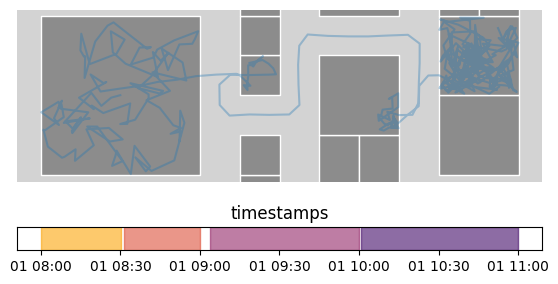

In [13]:
## Ground truth only 
traj = Charlie.trajectory
stops = Charlie.diary.dropna()

fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,3.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_pings(traj, ax=ax_map, radius=0.13, alpha=0, base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
ax_map.plot(traj.x, traj.y, alpha=0.35)
#ax_map.set_axis_off()
#plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.5, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')

ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('true_clusters.svg' , format='svg')
plt.savefig('true_clusters.png' , format='png', dpi=300)
plt.show()